In [1]:
import os

base_path = os.getcwd()
base_path = os.path.abspath(os.path.join(base_path, '..', '..'))
print("Base path:", base_path)

Base path: d:\tierra


In [2]:
import pandas as pd

# load the dataset
input_file = os.path.join(base_path, 'datasets', 'Mexico', 'Mexico_single_depth_orgc_merged.csv')
df = pd.read_csv(input_file)

pd.set_option('display.max_columns', None)  # Show all columns in the DataFrame

print("Loading dataset from:", input_file)
print("Dataset loaded with shape:", df.shape)
df.head()

Loading dataset from: d:\tierra\datasets\Mexico\Mexico_single_depth_orgc_merged.csv
Dataset loaded with shape: (3308, 17)


,profile_id,depth_category,date,longitude,latitude,clay,phaq,sand,silt,orgc,slopemean,bedrock,cfr,temperature,landcover,precipitation,ecoregion
0,1149115,0_30,2004-5-27,-92.924872,15.375747,12.576397,5.882000,42.139379,45.284223,11.860177,0.153699,rocas_metamorficas,0.001939,16.675776,Tropical húmeda,147.141876,Terrestre
1,1149116,0_30,2004-11-12,-93.805531,15.933933,9.141012,6.183665,86.473648,4.385340,7.997192,0.153699,rocas_metamorficas,0.001939,14.863654,Inundable o Transición tierra-mar,85.933456,Terrestre
2,1149118,0_30,1984-4-15,-92.340858,14.761703,21.426717,6.282607,49.860114,28.713169,15.670057,0.153699,rocas_igneas,0.001939,15.884959,Tropical húmeda,77.329765,Terrestre
3,1149120,0_30,1990-7-12,-104.979876,19.941109,9.880670,4.935505,72.640192,17.479138,2.013396,2.462867,rocas_igneas,2.349696,15.541919,Templada subhúmeda,159.122009,Terrestre
4,1149123,0_30,1990-7-7,-104.616548,19.695687,32.477529,4.309409,50.851700,16.670771,9.258772,0.459251,rocas_sedimentarias,0.221472,15.541919,Tropical subhúmeda,159.122009,Terrestre


In [3]:
# drop columns
drop_columns = [
    'profile_id',
    'depth_category',
    'date',
    'longitude',
    'latitude',
    'slopemean', 'temperature', 'precipitation', 'cfr',
    'bedrock', 'landcover', 'ecoregion' # categorical columns
]

df = df.drop(columns=drop_columns, errors='ignore')
print("Columns after dropping:", df.columns.tolist())

Columns after dropping: ['clay', 'phaq', 'sand', 'silt', 'orgc']


In [4]:
# Check for missing values
missing_values = df.isnull().sum()
print("\nMissing values count:")
print(missing_values[missing_values > 0] if any(missing_values > 0) else "No missing values found in the dataset")


Missing values count:
No missing values found in the dataset


d:\tierra\.venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 314.3960 - mae: 12.6064 - val_loss: 267.2073 - val_mae: 11.6362
Epoch 2/200
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 301.6148 - mae: 12.4696 - val_loss: 245.5166 - val_mae: 11.0092
Epoch 3/200
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 252.8622 - mae: 11.2747 - val_loss: 224.2558 - val_mae: 10.3470
Epoch 4/200
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 292.9272 - mae: 11.1509 - val_loss: 206.1082 - val_mae: 9.7311
Epoch 5/200
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 261.1774 - mae: 11.0362 - val_loss: 186.8293 - val_mae: 9.0027
Epoch 6/200
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 205.9749 - mae: 9.5956 - val_loss: 171.0151 - val_mae: 8.5247
Epoch 7/200
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 212.4053 - mae: 9.4885 - val_loss: 155.9816 - val_mae: 7.9208
Epoch 8/200
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 170.4791 - mae: 8.0835 - val_loss: 142.0169 - val_mae: 7.2975
Epoch 9/200
67/67 ━━━━━━

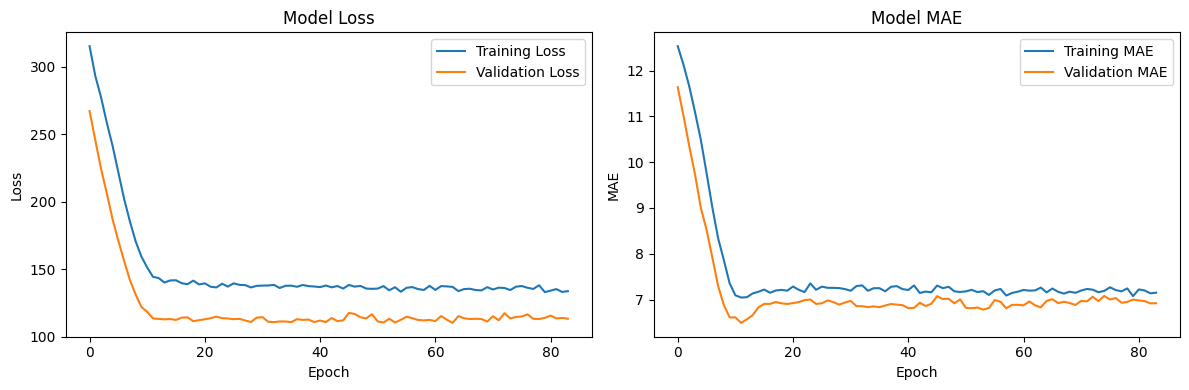

Mexico Deep learning model evaluation:
Test Loss (MSE): 80.1333
Test MAE: 6.2786
R-squared: 0.2656


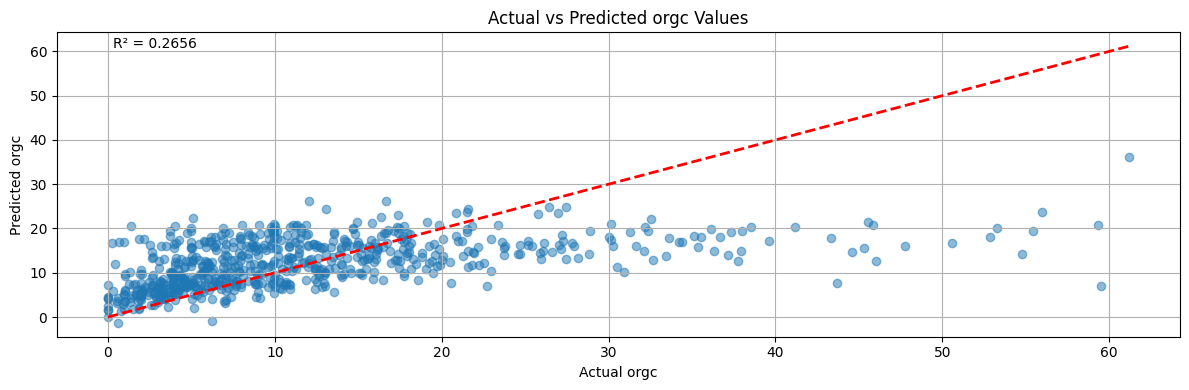

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input # type: ignore
from tensorflow.keras.callbacks import EarlyStopping # type: ignore

import matplotlib.pyplot as plt

# Prepare features and target
X = df.drop(['orgc'], axis=1)
y = df['orgc']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create the model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    BatchNormalization(),
    Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# Evaluate the model
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nTest MAE: {test_mae:.4f}")

# Make predictions
y_pred = model.predict(X_test_scaled)

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

# Plot regression line
plt.figure(figsize=(12, 4))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual orgc')
plt.ylabel('Predicted orgc')
plt.title('Actual vs Predicted orgc Values')

# Add R-squared value to plot
r2 = np.corrcoef(y_test, y_pred.flatten())[0, 1]**2
plt.text(0.05, 0.95, f'R² = {r2:.4f}', transform=plt.gca().transAxes)
plt.grid()

# Print all metrics MAE, MSE, R-squared
print(f"Mexico Deep learning model evaluation:")
print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"R-squared: {r2:.4f}")

plt.tight_layout()
plt.show()

In [6]:
new_df_path = os.path.join(base_path, 'datasets', 'UK_wosis_202312_orgc_soil_features_cleaned.csv')
new_df = pd.read_csv(new_df_path)
print("Loading UK dataset from:", new_df_path)

print("UK dataset loaded with shape:", new_df.shape)
new_df.head()

Loading UK dataset from: d:\tierra\datasets\UK_wosis_202312_orgc_soil_features_cleaned.csv
UK dataset loaded with shape: (300, 13)


,profile_id,latitude,longitude,upper_depth,lower_depth,date,clay,orgc,phaq,phca,sand,geometry,bedrock
0,1144922,52.083333,0.333333,0,25,1981-6-1,31.0,16.0,7.8,7.3,35.0,POINT (0.3333333333333932 52.08333333333332),rocas_igneas
1,1144922,52.083333,0.333333,25,41,1981-6-1,45.0,8.0,8.1,7.3,26.0,POINT (0.3333333333333932 52.08333333333332),rocas_igneas
2,1144922,52.083333,0.333333,41,92,1981-6-1,38.0,4.0,8.1,7.5,17.0,POINT (0.3333333333333932 52.08333333333332),rocas_igneas
3,1144922,52.083333,0.333333,92,120,1981-6-1,35.0,4.0,8.1,7.5,21.0,POINT (0.3333333333333932 52.08333333333332),rocas_igneas
4,1166040,52.083333,0.333333,0,25,1981-6-1,31.0,16.0,7.8,7.3,35.0,POINT (0.3333333333333932 52.08333333333332),rocas_igneas


In [7]:
# drop_columns
drop_columns_uk = [
    'profile_id',
    'date',
    'latitude',
    'longitude',
    'upper_depth',
    'lower_depth',
    'geometry',
    'bedrock'
]

new_df = new_df.drop(columns=drop_columns_uk, errors='ignore')
print("UK dataset columns after dropping:", new_df.columns.tolist())

UK dataset columns after dropping: ['clay', 'orgc', 'phaq', 'phca', 'sand']


In [8]:
from tensorflow.keras.models import clone_model # type: ignore
import seaborn as sns

# Function to evaluate and plot results
def evaluate_and_plot(y_true, y_pred, title):
    r2 = np.corrcoef(y_true, y_pred.flatten())[0, 1]**2
    mae = np.mean(np.abs(y_true - y_pred.flatten()))
    
    plt.figure(figsize=(12, 4))
    
    # Scatter plot
    plt.subplot(1, 2, 1)
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel('Actual orgc')
    plt.ylabel('Predicted orgc')
    plt.title(f'{title}\nR² = {r2:.4f}, MAE = {mae:.4f}')
    plt.grid(True)
    
    # Residuals plot
    plt.subplot(1, 2, 2)
    residuals = y_true - y_pred.flatten()
    plt.scatter(y_pred.flatten(), residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted orgc')
    plt.ylabel('Residuals')
    plt.title('Residuals Plot')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# Clone the existing model architecture
transfer_model = clone_model(model)
transfer_model.set_weights(model.get_weights())

# Freeze all layers except the last two
for layer in transfer_model.layers[:-2]:
    layer.trainable = False

# Compile the transfer model
transfer_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Prepare UK data similar to Mexican data
X_uk = new_df.drop(['orgc'], axis=1)
y_uk = new_df['orgc']

# Split UK data
X_uk_train, X_uk_test, y_uk_train, y_uk_test = train_test_split(
    X_uk, y_uk, test_size=0.2, random_state=42
)

# Scale UK data using the same scaler
X_uk_train_scaled = scaler.transform(X_uk_train)
X_uk_test_scaled = scaler.transform(X_uk_test)

# Fine-tune the model on UK data
history_uk = transfer_model.fit(
    X_uk_train_scaled, y_uk_train,
    validation_split=0.2,
    epochs=50,  # Fewer epochs for fine-tuning
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)

# Evaluate original model on UK test data
y_pred_original = model.predict(X_uk_test_scaled)
evaluate_and_plot(y_uk_test, y_pred_original, 'Original Model on UK Data')

# Evaluate fine-tuned model on UK test data
y_pred_transfer = transfer_model.predict(X_uk_test_scaled)
evaluate_and_plot(y_uk_test, y_pred_transfer, 'Transfer Learning Model on UK Data')

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_uk.history['loss'], label='Training Loss')
plt.plot(history_uk.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Fine-tuning')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_uk.history['mae'], label='Training MAE')
plt.plot(history_uk.history['val_mae'], label='Validation MAE')
plt.title('Model MAE During Fine-tuning')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- phca
Feature names seen at fit time, yet now missing:
- silt
